# In this file, we test the trained unet model on the 2p_5p NFI Dataset. Then we compare the metrics of the model compared to human specialists.

In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from DNAnet.data.data_models.hid_dataset import HIDDataset
from DNAnet.evaluation import *
from DNAnet.evaluation.segmentation.allele_metrics import *
from DNAnet.evaluation.segmentation.pixel_metrics import *

from config_io import load_model

In [15]:
images = HIDDataset(
  root="resources/data/2p_5p_Dataset_NFI/Raw data .HID files",
  panel="resources/data/SGPanel_PPF6C_SPOOR.xml",
  annotations_path="resources/data/2p_5p_Dataset_NFI/.txt bestanden 2024 naam",
  hid_to_annotations_path="resources/data/2p_5p_Dataset_NFI/2p_5p_hid_to_annotation.csv",
  limit=1,
  adjustment_of_annotations='top',
  ground_truth_as_annotations=False
)

2025-10-08 13:22:25 INFO     Loading data from file
2025-10-08 13:22:25 INFO     Walking directory to retrieve all hid files...
Processing folders: 100%|██████████| 20/20 [00:00<00:00, 7069.45it/s]
2025-10-08 13:22:25 INFO     Found 350 HIDs
2025-10-08 13:22:25 INFO     Found 0 HIDs without ladder
2025-10-08 13:22:25 INFO     Removed 0 HIDs without annotation
2025-10-08 13:22:25 INFO     Limiting dataset to 1
Loading data from resources/data/2p_5p_Dataset_NFI/Raw data .HID files: 100%|██████████| 1/1 [00:00<00:00, 14.03it/s]
2025-10-08 13:22:25 INFO     Adjusting image annotations (type top).


In [18]:
# images[0].meta['called_alleles_manual'][2], 
images[0].meta['called_alleles'][2]

Marker(dye_row=0, name='D1S1656', alleles=[Allele(name='11', base_pair=165.75107296137338, left_bin=165.25107296137338, right_bin=166.25107296137338, height=4114.0), Allele(name='14', base_pair=178.02575107296138, left_bin=177.62575107296138, right_bin=178.52575107296138, height=4097.0), Allele(name='15', base_pair=182.00873362445415, left_bin=181.60873362445415, right_bin=182.50873362445415, height=875.0), Allele(name='16', base_pair=186.11353711790392, left_bin=185.7135371179039, right_bin=186.61353711790392, height=132.0), Allele(name='17', base_pair=190.2183406113537, left_bin=189.8183406113537, right_bin=190.7183406113537, height=524.0)])

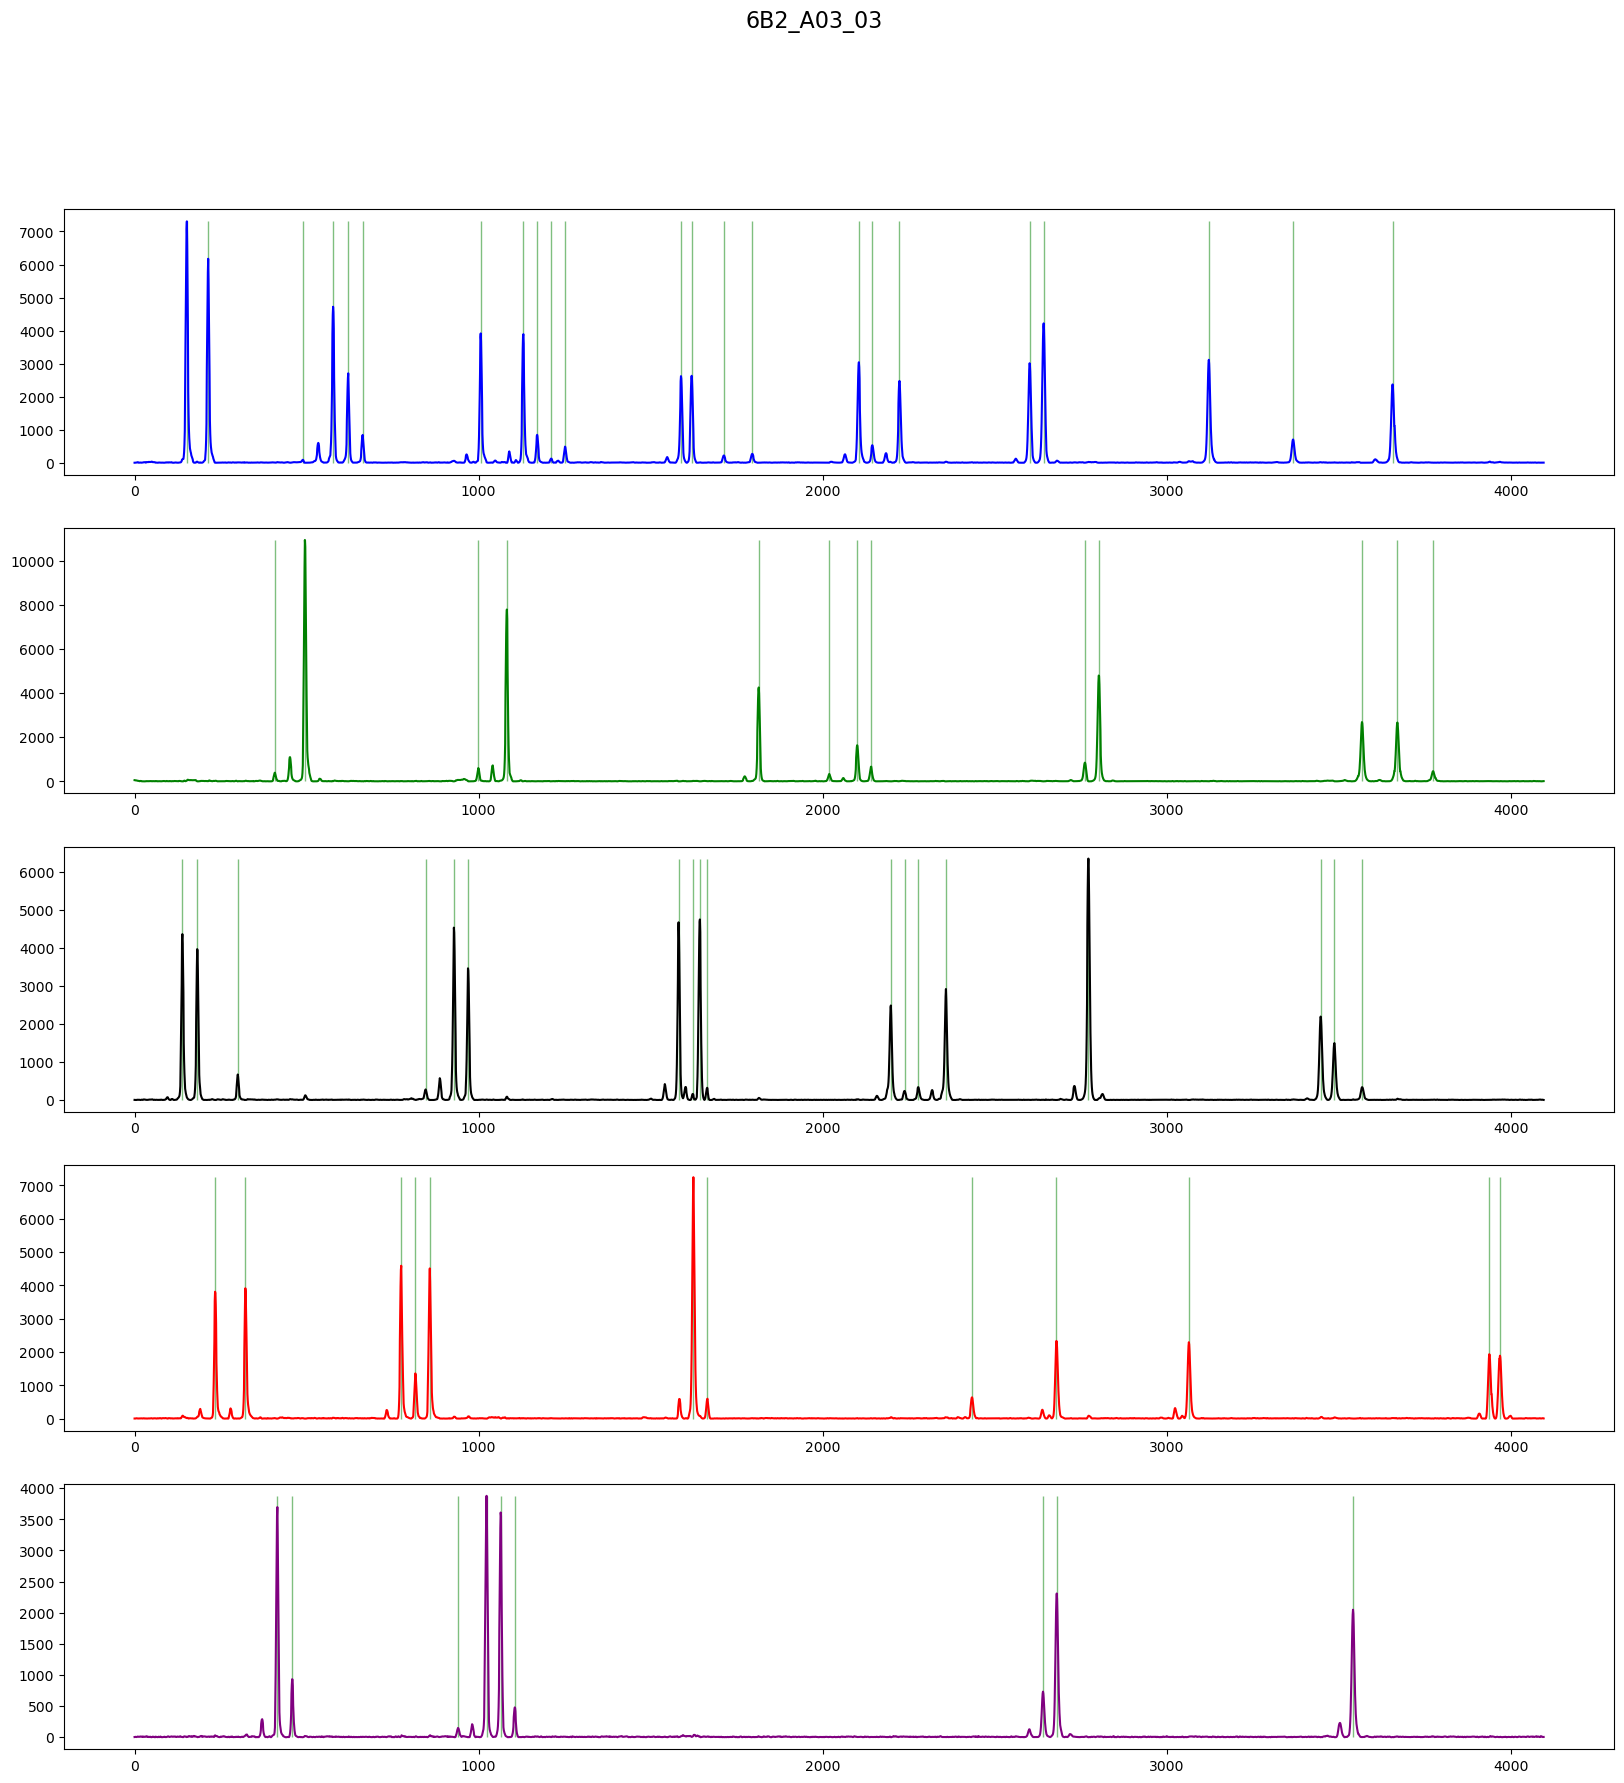

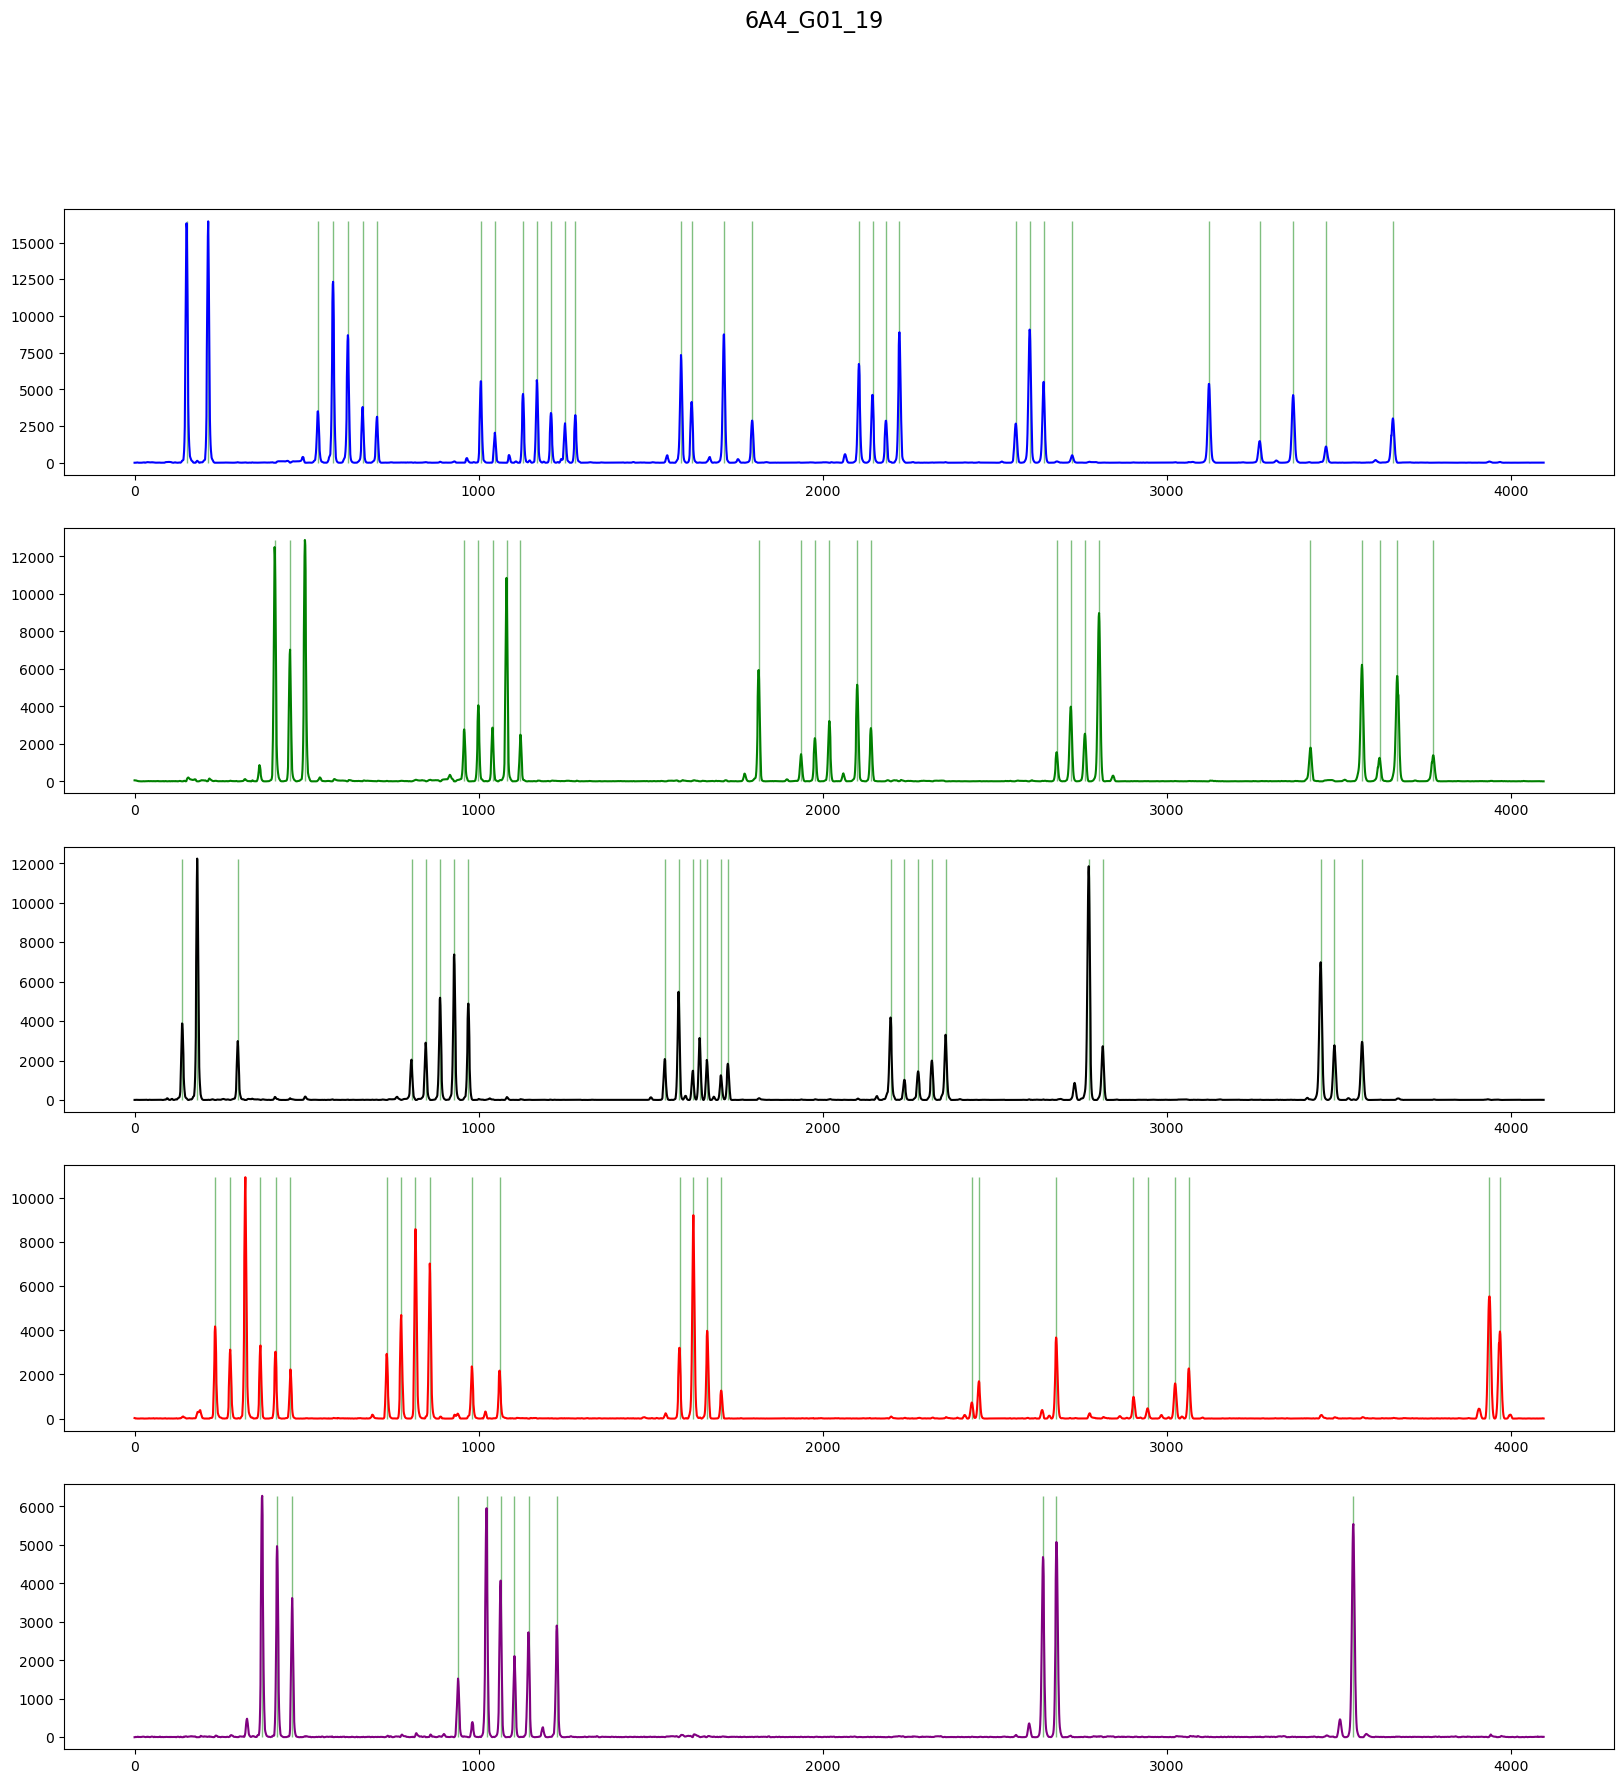

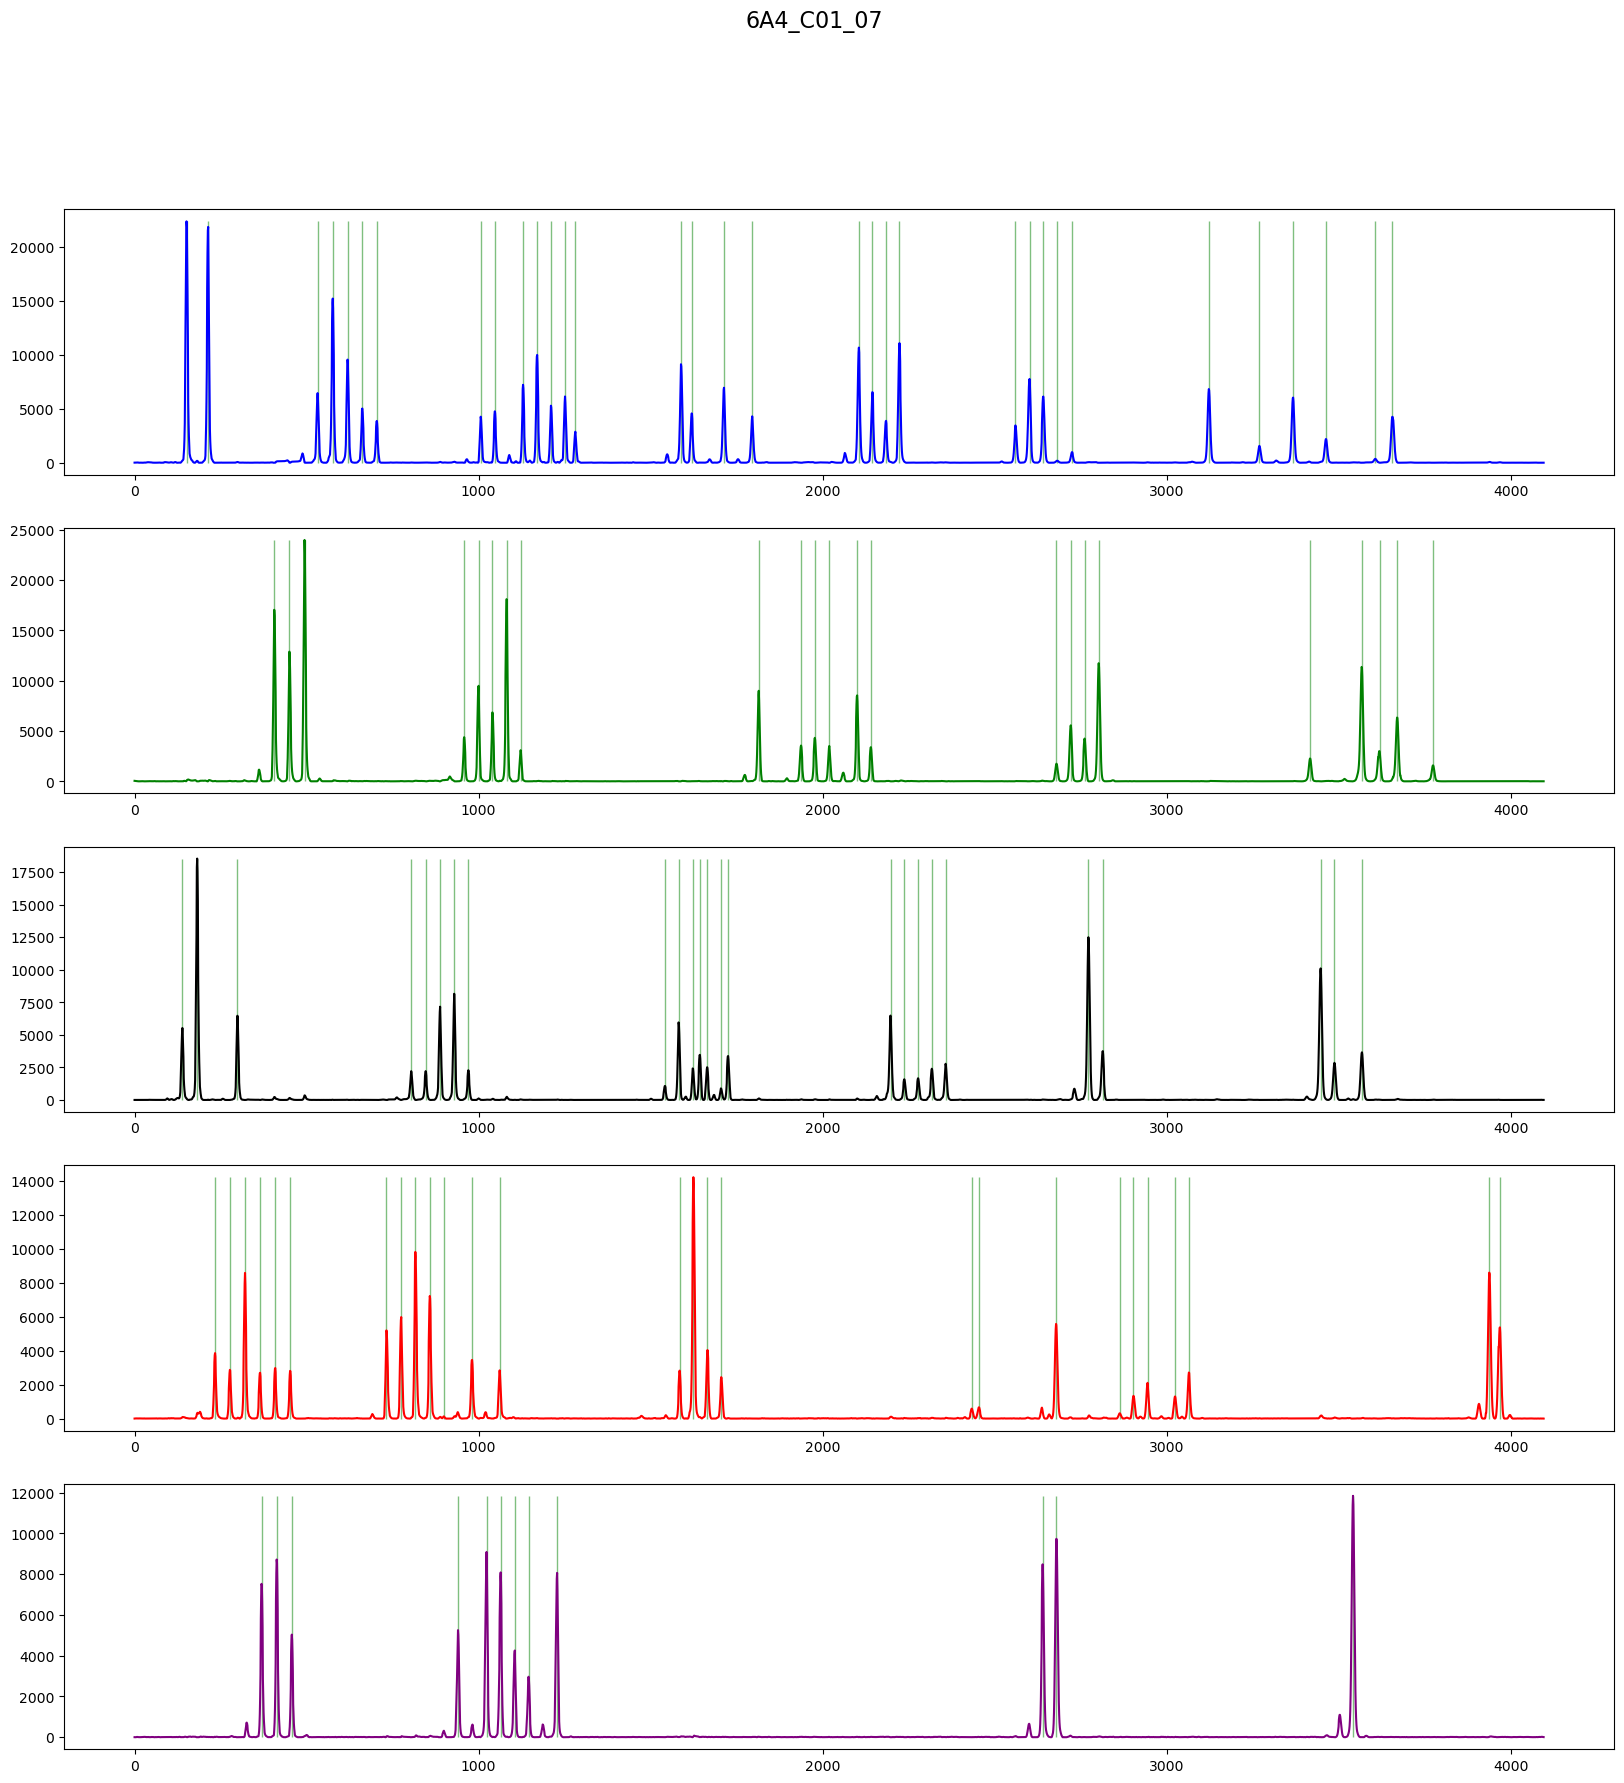

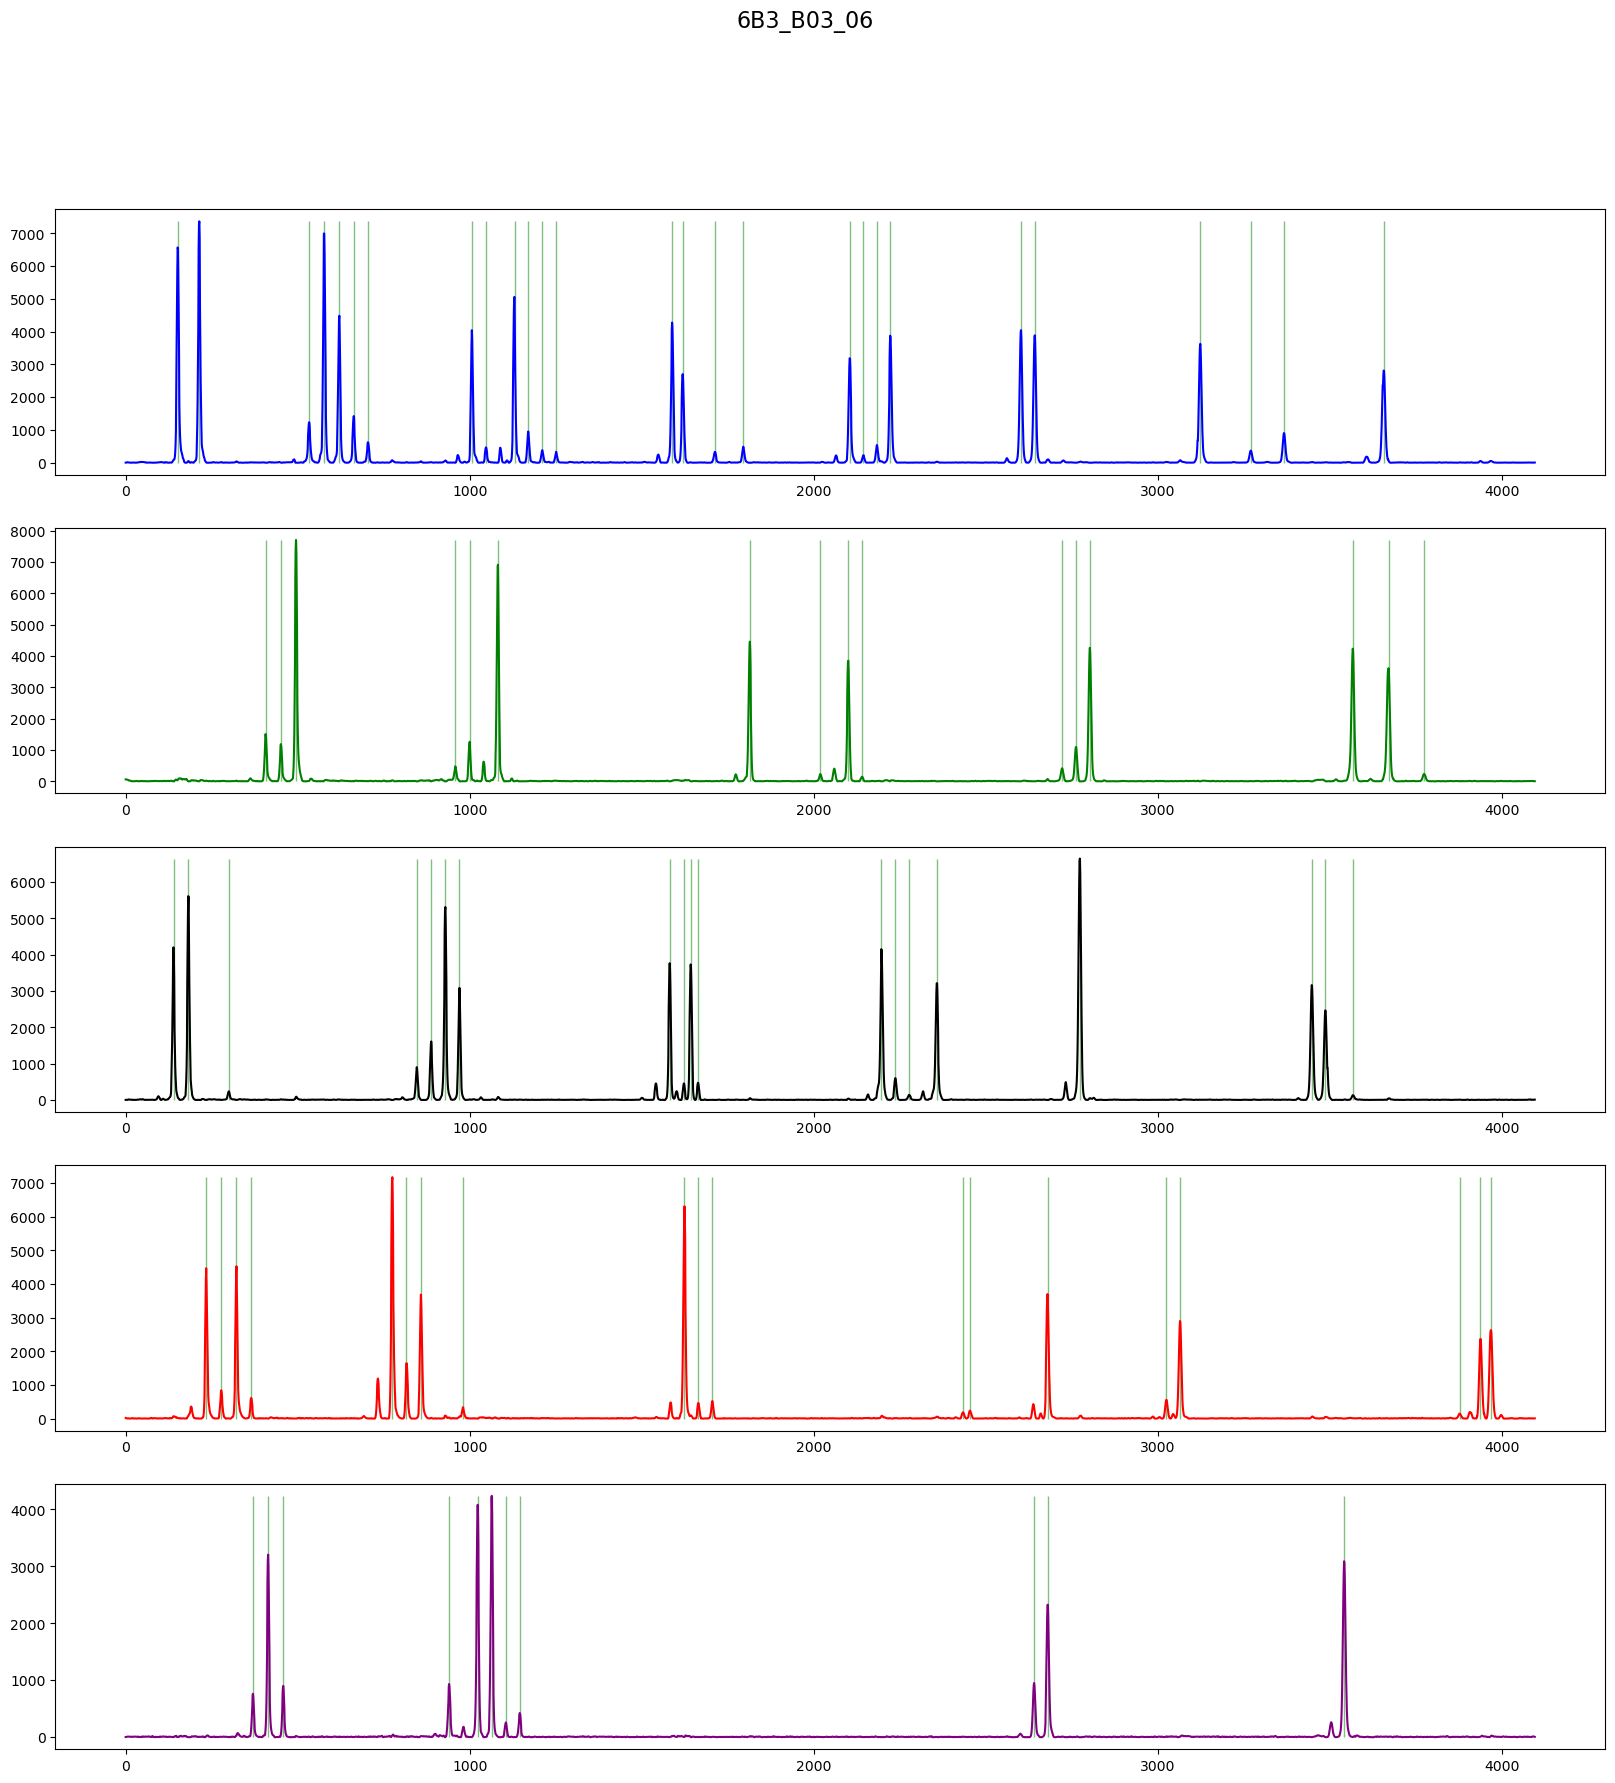

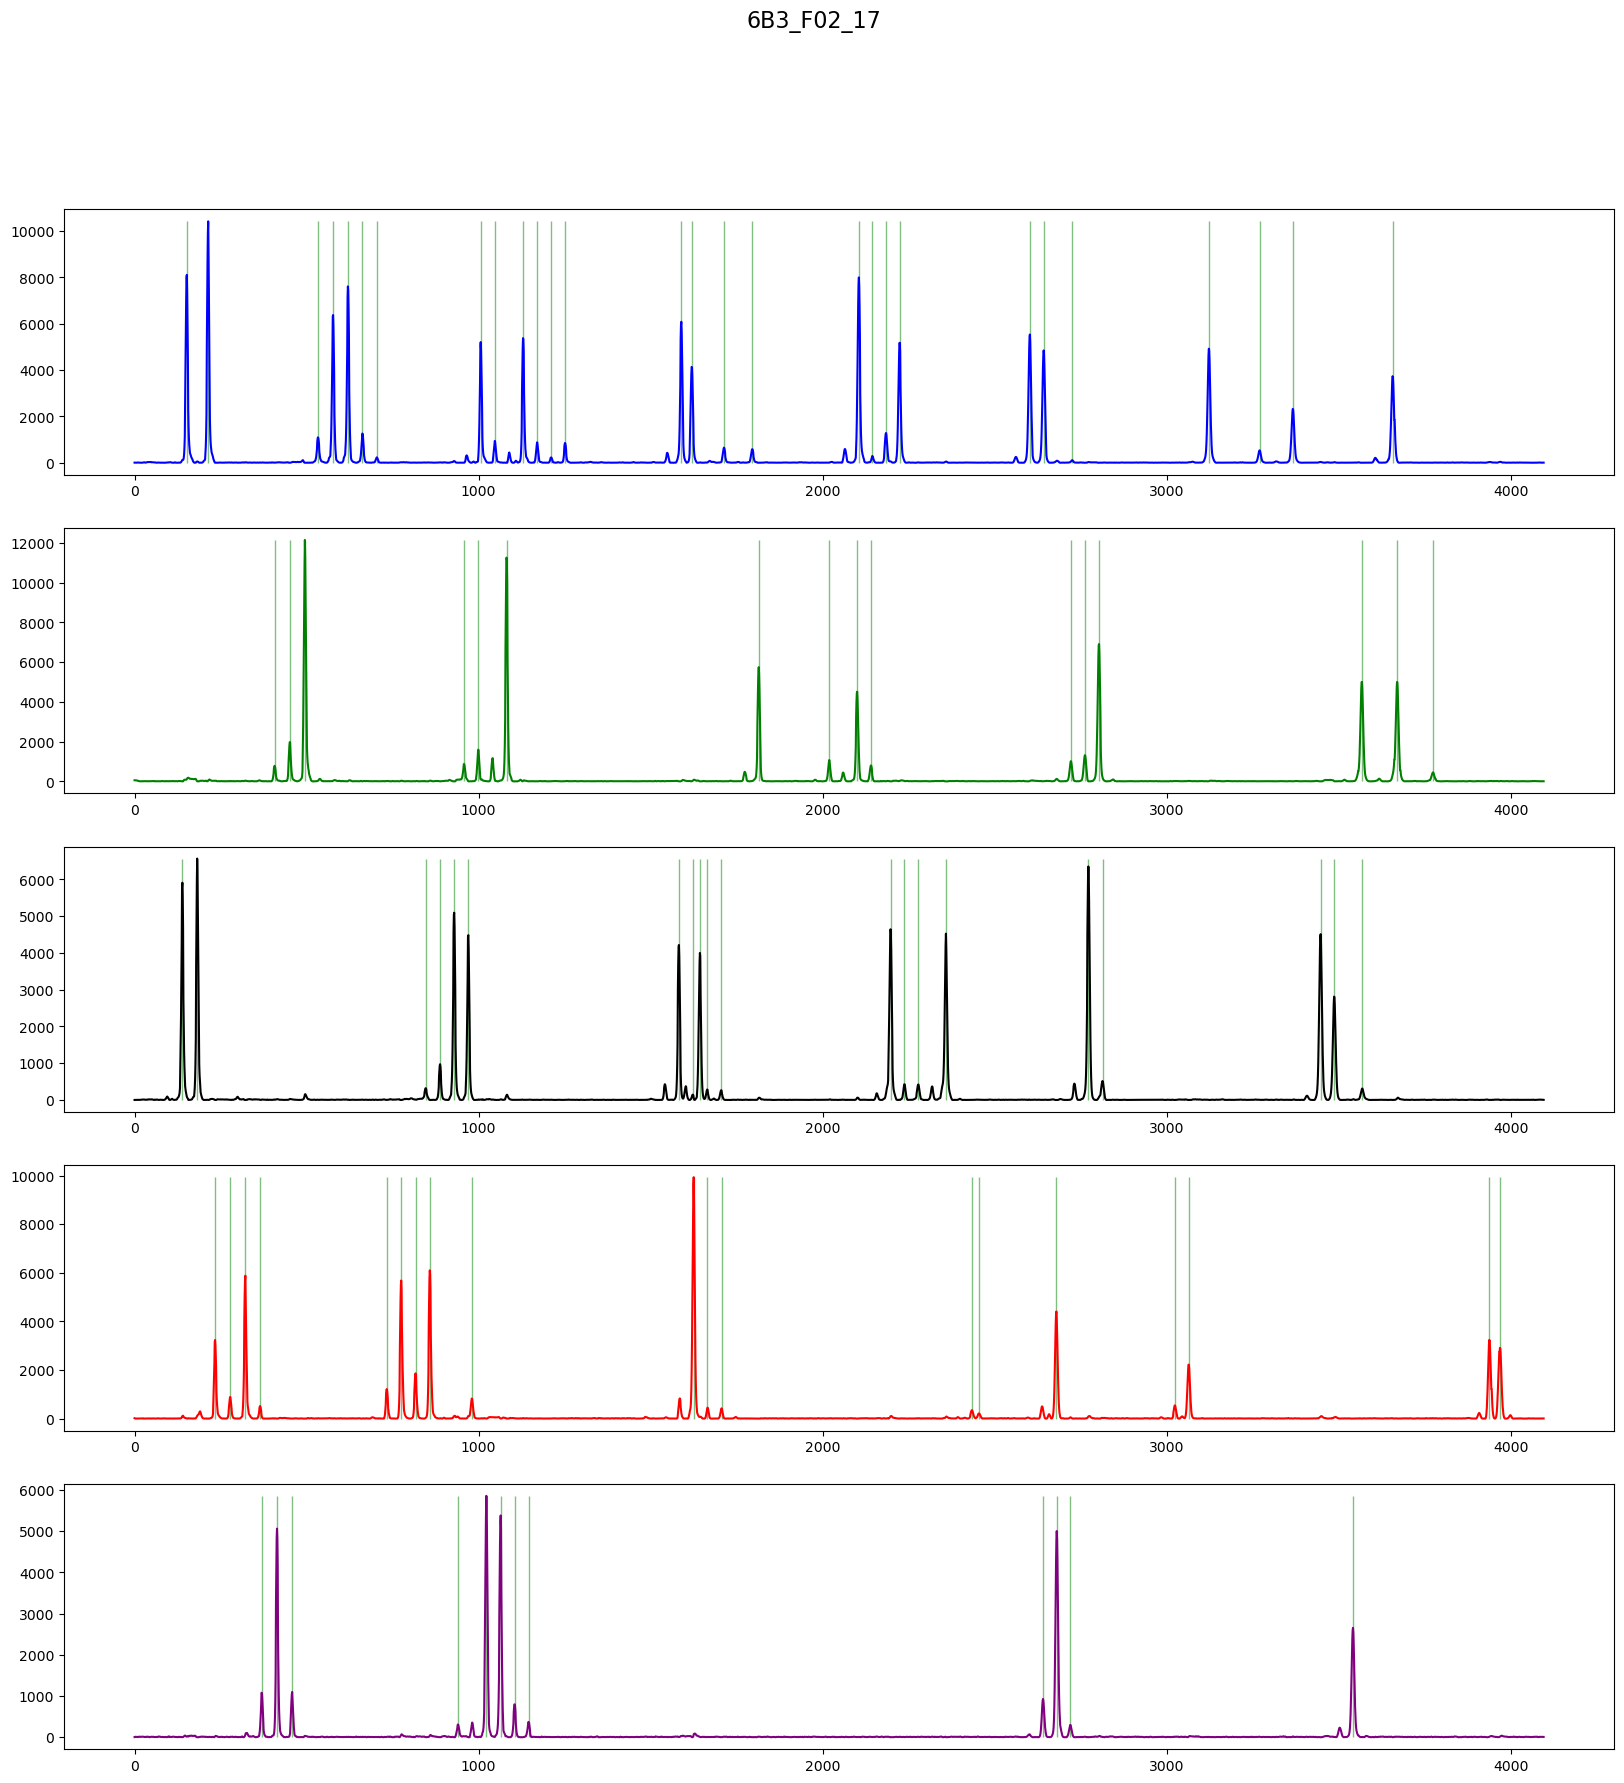

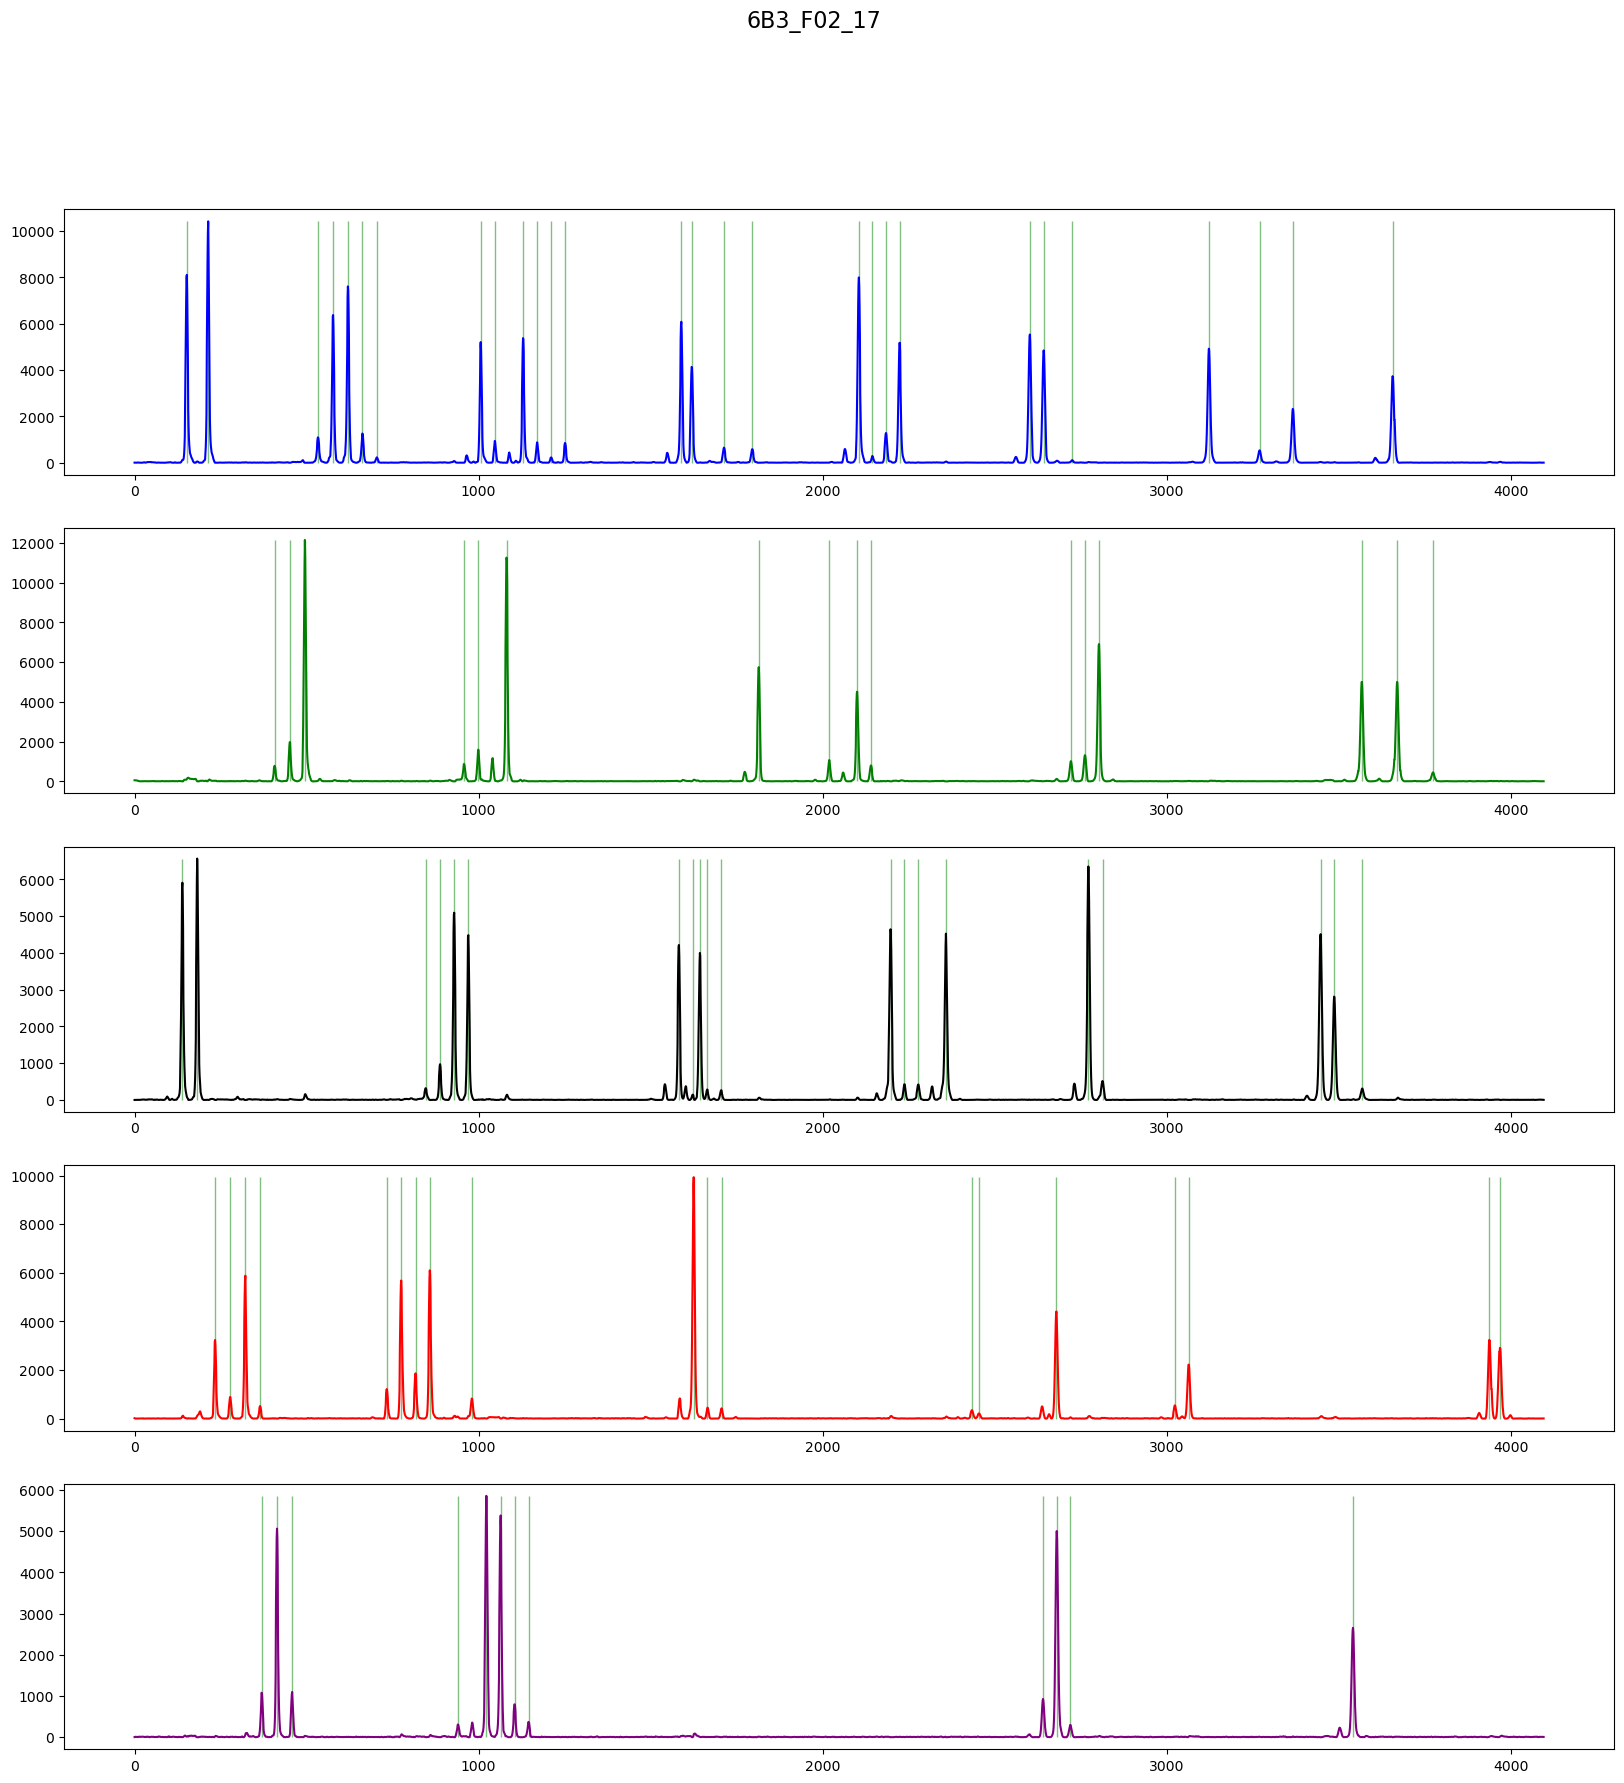

In [4]:
from DNAnet.evaluation.visualizations import plot_profile


plot_profile(images)

In [5]:
my_unet_model = load_model("config/models/unet_advanced.yaml")
my_unet_model.load("output/ProvedIt_best_unet/20250926_142826/checkpoint/")

unet_model = load_model("config/models/unet.yaml")
unet_model.load("resources/model/current_best_unet/")

In [6]:
my_predictions = my_unet_model.predict_batch(images)
predictions = unet_model.predict_batch(images)

2025-10-08 13:14:07 INFO     Calling alleles from predicted segmentation...
2025-10-08 13:14:43 INFO     Calling alleles from predicted segmentation...


In [7]:
# current issue: we are also retrieving ladder files, and other files not conforming to the standard
print('allele u-net f1: ', allele_f1_score(images, predictions))
print('allele u-net precision: ', allele_precision(images, predictions))
print('allele u-net recall: ', allele_recall(images, predictions))

# Add pixel metrics as well
print('pixel u-net f1: ', pixel_f1_score(images, predictions))
print('pixel u-net precision: ', pixel_precision(images, predictions))
print('pixel u-net recall: ', pixel_recall(images, predictions))

allele u-net f1:  0.9781181619256017
allele u-net precision:  0.9889380530973452
allele u-net recall:  0.9675324675324676
pixel u-net f1:  0.9737903225806451
pixel u-net precision:  0.9777327935222672
pixel u-net recall:  0.9698795180722891


allele u-net f1:  0.9781181619256017
allele u-net precision:  0.9889380530973452
allele u-net recall:  0.9675324675324676
pixel u-net f1:  0.9737903225806451
pixel u-net precision:  0.9777327935222672
pixel u-net recall:  0.9698795180722891

In [8]:
# current issue: we are also retrieving ladder files, and other files not conforming to the standard
print('allele u-net f1: ', allele_f1_score(images, my_predictions))
print('allele u-net precision: ', allele_precision(images, my_predictions))
print('allele u-net recall: ', allele_recall(images, my_predictions))

# Add pixel metrics as well
print('pixel u-net f1: ', pixel_f1_score(images, my_predictions))
print('pixel u-net precision: ', pixel_precision(images, my_predictions))
print('pixel u-net recall: ', pixel_recall(images, my_predictions))

allele u-net f1:  0.9421841541755889
allele u-net precision:  0.9322033898305084
allele u-net recall:  0.9523809523809523
pixel u-net f1:  0.9067713444553485
pixel u-net precision:  0.8867562380038387
pixel u-net recall:  0.927710843373494


allele u-net f1:  0.9421841541755889
allele u-net precision:  0.9322033898305084
allele u-net recall:  0.9523809523809523
pixel u-net f1:  0.9067713444553485
pixel u-net precision:  0.8867562380038387
pixel u-net recall:  0.927710843373494

## 30 Mixtures:
### Mine:
allele u-net f1:  0.9269633957724694
allele u-net precision:  0.9387399930386355
allele u-net recall:  0.9154786150712831

### Original:
allele u-net f1:  0.9696233292831107
allele u-net precision:  0.9921847246891652
allele u-net recall:  0.9480651731160896